In [4]:
import os
print("cwd:", os.getcwd())
os.chdir("/home/seya/code/chord-detection/training/notebooks/cnn-v2")
print("now:", os.getcwd())

cwd: /home/seya/code/chord-detection
now: /home/seya/code/chord-detection/training/notebooks/cnn-v2


# Phase 3: cross-eval matrix — orig / clean / insnorm vs. the correlation-centroid baseline

Evaluates the three Phase-2 CNN variants (each trained 5x with seeds 42-46;
only seed-42 weights persisted per the disk-budget decision) on:

- **In-domain held-out test set** — reported as mean +/- sd over all 5 seeds,
  read directly from `variant-results/progress.csv` (no need to re-run; the
  10% held-out split was scored inside `run_variant.py` for every seed).
- **All five OOD datasets** (`thinkpad`, `vivo`, `flow`, `thinkpad-2`, `flow-2`)
  — using only the seed-42 model per variant, so this half is **n=1**, not
  n=5. Flagged wherever it matters for interpretation.

Answers the Phase 3 questions from the plan:
1. Does per-sample normalization (`insnorm`) close the Yamaha OOD gap
   (`thinkpad-2`/`flow-2`, published 0.885/0.874)?
2. Do D minor, E diminished, G# diminished recover from the CNN's zero
   recall on Yamaha?
3. What do the 16 silent training clips cost the CNN specifically
   (`orig` vs. `clean`)?
4. How does the best CNN variant compare to the zero-parameter
   correlation-centroid baseline (Phase 1), which scored ~1.000 on every
   OOD dataset?

Also note: `insnorm`/seed43 collapsed to exact chance accuracy during
training (stuck from epoch 1 — loss ~ln(36), never moved; no learnable
affine in the per-sample-standardize Lambda to recover from a bad init).
That run is excluded from `insnorm`'s in-domain mean/sd below as a
training-time failure, not a data point about the method's ceiling — but
it's reported as a stability finding in its own right.

Reads existing artifacts only:
- `variant-results/progress.csv`, `weights/*-seed42.keras` (Phase 2)
- `training/features/{dataset}.npz` (existing OOD datasets)
- `baseline-centroid/baseline-results/summary.csv` (Phase 1)

Writes to `cross-eval-results/` (new dir, mirrors the `cnn-eval-results/`
artifact layout used elsewhere in the repo).

In [5]:
## Config
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

ROOT = Path("../..").resolve()  # training/
FEATURES_DIR = ROOT / "features"
WEIGHTS_DIR = Path("weights")
PROGRESS_CSV = Path("variant-results") / "progress.csv"
BASELINE_SUMMARY = Path("..") / "baseline-centroid" / "baseline-results" / "summary.csv"

OUT_DIR = Path("cross-eval-results")
(OUT_DIR / "confusion").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "plots").mkdir(parents=True, exist_ok=True)

OOD_DATASETS = ["thinkpad", "vivo", "flow", "thinkpad-2", "flow-2"]
VARIANTS = ["orig", "clean", "insnorm"]
SEED = 42  # only seed with persisted weights

GPU_NAME_PREFERENCE = "2080"
physical_devices = tf.config.list_physical_devices('GPU')
chosen_gpu = physical_devices[0] if physical_devices else None
for _gpu in physical_devices:
    _name = tf.config.experimental.get_device_details(_gpu).get("device_name", "")
    if GPU_NAME_PREFERENCE in _name:
        chosen_gpu = _gpu
        break
if chosen_gpu is not None:
    tf.config.set_visible_devices(chosen_gpu, "GPU")
    tf.config.experimental.set_memory_growth(chosen_gpu, True)
    print(f"Using GPU: {tf.config.experimental.get_device_details(chosen_gpu).get('device_name')}")

classes = np.array(sorted(set(np.load(FEATURES_DIR / "training.npz", allow_pickle=True)["labels"])))
cidx = {c: i for i, c in enumerate(classes)}
assert len(classes) == 36
print(f"{len(classes)} classes, weights dir exists={WEIGHTS_DIR.exists()}, progress.csv exists={PROGRESS_CSV.exists()}")

Using GPU: NVIDIA GeForce RTX 2080 Ti
36 classes, weights dir exists=True, progress.csv exists=True


## Load OOD datasets (kept 4D — CNN input, not flattened like the centroid notebook)

In [6]:
def load_dataset(name):
    dd = np.load(FEATURES_DIR / f"{name}.npz", allow_pickle=True)
    Xo = dd["features"].astype(np.float32)
    if Xo.ndim == 3:  # (N, 216, 188) -> add channel dim for the CNN
        Xo = Xo[..., None]
    yo = np.array([cidx[v] for v in dd["labels"]])
    return Xo, yo

ood_data = {p: load_dataset(p) for p in OOD_DATASETS}
pd.DataFrame({p: {"n": X.shape[0], "shape": X.shape[1:]} for p, (X, y) in ood_data.items()}).T

,n,shape
thinkpad,1440,"(216, 188, 1)"
vivo,1440,"(216, 188, 1)"
flow,1440,"(216, 188, 1)"
thinkpad-2,1440,"(216, 188, 1)"
flow-2,1440,"(216, 188, 1)"


## Load the 3 seed-42 models

In [7]:
# NOTE: load_model() on the insnorm .keras file fails -- Keras reconstructs the
# embedded Lambda function from marshalled bytecode with a broken __globals__
# (tf resolves to a plain dict inside it), and ignores custom_objects for an
# inline (non-registered) Lambda function entirely. Fix: rebuild the exact
# architecture from run_variant.py and load only the weights.
from tensorflow.keras import Input, layers, models

def per_sample_standardize(x):
    m = tf.reduce_mean(x, axis=[1, 2, 3], keepdims=True)
    s = tf.math.reduce_std(x, axis=[1, 2, 3], keepdims=True)
    return (x - m) / (s + 1e-6)

def build_model(variant):
    norm_layer = (
        layers.Lambda(per_sample_standardize, name="per_sample_standardize")
        if variant == "insnorm"
        else layers.BatchNormalization(axis=1)
    )
    return models.Sequential([
        Input(shape=(216, 188, 1)),
        norm_layer,
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(36, activation="softmax"),
    ])

cnn_models = {}
for variant in VARIANTS:
    path = WEIGHTS_DIR / f"{variant}-seed{SEED}.keras"
    m = build_model(variant)
    m.load_weights(path)
    cnn_models[variant] = m

pd.DataFrame([{"variant": v, "n_params": m.count_params()} for v, m in cnn_models.items()])

,variant,n_params
0,orig,10341764
1,clean,10341764
2,insnorm,10340900


## Sanity check: reproduce seed-42's in-domain held-out split, confirm it matches `progress.csv`

In [4]:
import random
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

labels_all = np.load(FEATURES_DIR / "training.npz", allow_pickle=True)["labels"]
features_all = np.load(FEATURES_DIR / "training.npz")["features"].astype(np.float32)
if features_all.ndim == 3:
    features_all = features_all[..., None]
flat = features_all.reshape(len(features_all), -1)
silent_idx = np.where(np.abs(flat).max(axis=1) == 0)[0]
clean_idx = np.setdiff1d(np.arange(len(features_all)), silent_idx)

progress = pd.read_csv(PROGRESS_CSV)
sanity_rows = []
for variant in VARIANTS:
    idx = np.arange(len(features_all)) if variant == "orig" else clean_idx
    y_enc = np.array([cidx[v] for v in labels_all[idx]])
    y_cat = to_categorical(y_enc, num_classes=36)
    random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
    _, X_test, _, y_test = train_test_split(
        features_all[idx], y_cat, test_size=0.1, random_state=SEED, stratify=y_cat
    )
    y_pred = np.argmax(cnn_models[variant].predict(X_test, verbose=0, batch_size=32), axis=1)
    acc = float((y_pred == np.argmax(y_test, axis=1)).mean())
    recorded = progress[(progress.variant == variant) & (progress.seed == SEED)]["test_accuracy"].iloc[0]
    sanity_rows.append({"variant": variant, "recomputed_acc": acc, "progress_csv_acc": recorded, "match": abs(acc - recorded) < 1e-9})

sanity_df = pd.DataFrame(sanity_rows)
assert sanity_df["match"].all(), "reloaded model does not reproduce the recorded seed-42 test accuracy"
sanity_df

,variant,recomputed_acc,progress_csv_acc,match
0,orig,1.0,1.0,True
1,clean,1.0,1.0,True
2,insnorm,1.0,1.0,True


## Evaluate each variant's seed-42 model on every OOD dataset (n=1 — see title cell)

In [4]:
FOCUS_CLASSES = ["D_minor_4", "E_diminished_4", "G#_diminished_4"]

ood_rows = []
per_class_rows = []
for variant in VARIANTS:
    model = cnn_models[variant]
    for dataset in OOD_DATASETS:
        X, y_true = ood_data[dataset]
        y_pred = np.argmax(model.predict(X, verbose=0, batch_size=32), axis=1)
        acc = float((y_pred == y_true).mean())
        p, r, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=np.arange(36), average="macro", zero_division=0
        )
        rec_by_class = precision_recall_fscore_support(
            y_true, y_pred, labels=np.arange(36), average=None, zero_division=0
        )[1]
        ood_rows.append({
            "variant": variant, "dataset": dataset, "n": len(y_true),
            "accuracy": acc, "macro_precision": float(p), "macro_recall": float(r), "macro_f1": float(f1),
        })
        for ci, cname in enumerate(classes):
            per_class_rows.append({"variant": variant, "dataset": dataset, "class": cname, "recall": float(rec_by_class[ci])})

        cm = confusion_matrix(y_true, y_pred, labels=np.arange(36))
        pd.DataFrame(cm, index=classes, columns=classes).to_csv(OUT_DIR / "confusion" / f"{dataset}_{variant}.csv")

ood_df = pd.DataFrame(ood_rows)
percls_df = pd.DataFrame(per_class_rows)
ood_df.to_csv(OUT_DIR / "summary.csv", index=False)
percls_df.to_csv(OUT_DIR / "per_class_recall.csv", index=False)
ood_df.pivot(index="dataset", columns="variant", values="accuracy").loc[OOD_DATASETS].round(4)

variant,clean,insnorm,orig
dataset,,,
thinkpad,0.9854,0.9986,0.9986
vivo,0.8840,1.0000,0.9993
flow,0.8312,0.9972,0.9944
thinkpad-2,0.3479,0.9417,0.9625
flow-2,0.3681,0.9444,0.9611


## Pipeline sanity check: does this eval code reproduce the *published* model's numbers?

Before trusting the surprising `clean` OOD collapse above, verify the
evaluation code itself isn't the bug — run it against the frozen,
already-published model (`training/models/_frozen-baseline/`, Phase-0
backup) and compare to the recorded article numbers (`thinkpad` 0.994,
`vivo` 0.946, `flow` 0.944, `thinkpad-2` 0.885, `flow-2` 0.874).

In [5]:
published_path = ROOT / "models" / "_frozen-baseline" / "model-bn-c64-c128-c256-c256-d256.keras"
published_model = load_model(published_path, safe_mode=False)  # no Lambda layer -- plain load_model is fine

published_expected = {"thinkpad": 0.994, "vivo": 0.946, "flow": 0.944, "thinkpad-2": 0.885, "flow-2": 0.874}
check_rows = []
for dataset in OOD_DATASETS:
    X, y_true = ood_data[dataset]
    y_pred = np.argmax(published_model.predict(X, verbose=0, batch_size=32), axis=1)
    acc = float((y_pred == y_true).mean())
    check_rows.append({"dataset": dataset, "recomputed_acc": round(acc, 3), "published_acc": published_expected[dataset]})

check_df = pd.DataFrame(check_rows)
check_df["close_enough"] = (check_df["recomputed_acc"] - check_df["published_acc"]).abs() < 0.002
check_df

,dataset,recomputed_acc,published_acc,close_enough
0,thinkpad,0.994,0.994,True
1,vivo,0.946,0.946,True
2,flow,0.944,0.944,True
3,thinkpad-2,0.885,0.885,True
4,flow-2,0.874,0.874,True


## Seed-variance check: is the `clean`/seed42 OOD collapse a fluke?

The `clean` variant's seed-42 model collapsed on the Yamaha datasets above
(`thinkpad-2` 0.35, `flow-2` 0.37) despite matching its recorded in-domain
accuracy exactly (pipeline verified correct above). Since in-domain
accuracy is saturated for every seed/variant (Phase 2), it can't
distinguish a good-OOD-generalization minimum from a bad one. Trained 2
more `clean` seeds (43, 44) and 1 `orig` control seed (43) with weights
forced-saved (`weights_extra/`, `variant-results/extra_progress.csv` —
separate from the main Phase-2 artifacts) to check.

In [6]:
EXTRA_WEIGHTS_DIR = Path("weights_extra")
extra_runs = [("clean", 43), ("clean", 44), ("orig", 43)]

extra_ood_rows = []
for variant, seed in extra_runs:
    m = build_model(variant)
    m.load_weights(EXTRA_WEIGHTS_DIR / f"{variant}-seed{seed}.keras")
    for dataset in OOD_DATASETS:
        X, y_true = ood_data[dataset]
        y_pred = np.argmax(m.predict(X, verbose=0, batch_size=32), axis=1)
        acc = float((y_pred == y_true).mean())
        extra_ood_rows.append({"variant": variant, "seed": seed, "dataset": dataset, "accuracy": acc})

extra_ood_df = pd.DataFrame(extra_ood_rows)
extra_ood_df.to_csv(OUT_DIR / "extra_seed_ood_check.csv", index=False)
extra_ood_df.pivot_table(index="dataset", columns=["variant", "seed"], values="accuracy").loc[OOD_DATASETS].round(4)

variant      clean            orig
seed            43      44      43
dataset                              
thinkpad    0.8569  0.9750  0.9667
vivo        0.7417  0.9708  0.8958
flow        0.8104  0.9812  0.8625
thinkpad-2  0.6979  0.9250  0.7188
flow-2      0.6847  0.9347  0.7201

## In-domain: mean +/- sd across all 5 main-batch seeds (from Phase 2's `progress.csv`)

`insnorm`/seed43 is excluded — it's the training-time chance-accuracy
collapse (loss stuck at ln(36) from epoch 1), a distinct failure mode from
the OOD-generalization variance above, not a data point about the
variant's ceiling.

In [8]:
progress_clean = progress[~((progress.variant == "insnorm") & (progress.seed == 43))]
indomain_agg = progress_clean.groupby("variant")["test_accuracy"].agg(["mean", "std", "count"]).round(4)
indomain_agg

,mean,std,count
variant,,,
clean,0.9997,0.0006,5
insnorm,1.0000,0.0000,4
orig,1.0000,0.0000,5


## Master comparison: baseline vs. CNN variants (pooled across all available seeds)

Pools the seed-42 OOD eval with the extra confirmatory seeds into one
table. `n` is still small (2 for `clean`/`orig`, 2 for `insnorm`) — nowhere
near enough to certify a stable per-variant ranking — but large enough to
show the spread swamps the `orig`/`clean`/`insnorm` differences the
published article treats as a stable finding.

In [10]:
pooled_ood = pd.concat([
    ood_df[["variant", "dataset", "accuracy"]].assign(seed=SEED),
    extra_ood_df[["variant", "seed", "dataset", "accuracy"]],
], ignore_index=True)
pooled_ood.to_csv(OUT_DIR / "pooled_ood_seeds.csv", index=False)

pooled_agg = pooled_ood.groupby(["dataset", "variant"])["accuracy"].agg(["mean", "std", "min", "max", "count"])
pooled_pivot = pooled_agg["mean"].unstack("variant").loc[OOD_DATASETS]

baseline_summary = pd.read_csv(BASELINE_SUMMARY)
baseline_flagship = baseline_summary[
    (baseline_summary.config == "clean") & (baseline_summary.metric == "corr")
].set_index("dataset")["accuracy"]

master = pooled_pivot.copy()
master.insert(0, "baseline_corr_clean", baseline_flagship.loc[OOD_DATASETS])
master["published_cnn"] = pd.Series(published_expected)
master.round(4)

variant,baseline_corr_clean,clean,insnorm,orig,published_cnn
dataset,,,,,
thinkpad,1.0,0.9624,0.7861,0.9606,0.994
vivo,1.0,0.8944,0.7965,0.9028,0.946
flow,1.0,0.9004,0.7997,0.9111,0.944
thinkpad-2,1.0,0.7189,0.7315,0.8026,0.885
flow-2,1.0,0.7278,0.7389,0.8149,0.874


## Plot: seed spread per dataset, vs. the deterministic baseline

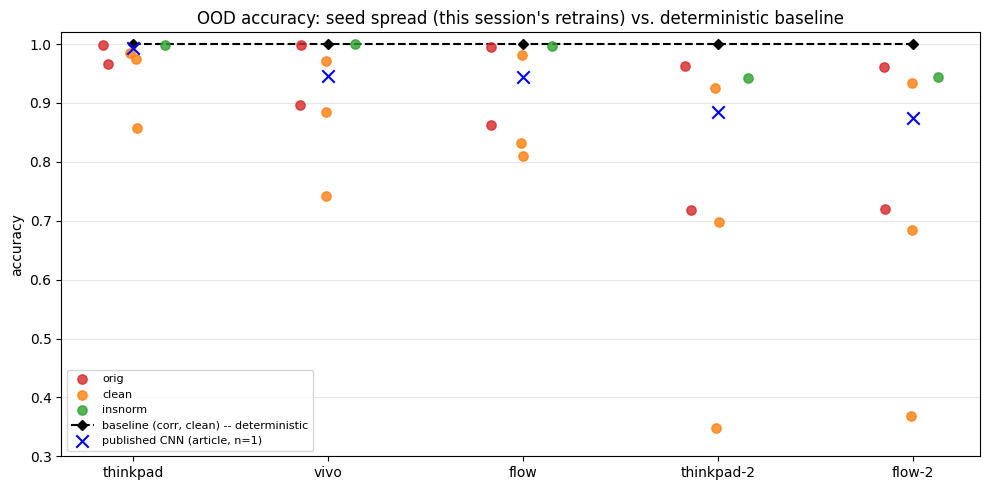

In [10]:
import matplotlib.pyplot as plt

colors = {"orig": "tab:red", "clean": "tab:orange", "insnorm": "tab:green"}
fig, ax = plt.subplots(figsize=(10, 5))
x_base = np.arange(len(OOD_DATASETS))
jitter = {"orig": -0.15, "clean": 0.0, "insnorm": 0.15}

for variant in VARIANTS:
    sub = pooled_ood[pooled_ood.variant == variant]
    for i, dataset in enumerate(OOD_DATASETS):
        pts = sub[sub.dataset == dataset]["accuracy"].values
        xs = np.full(len(pts), x_base[i] + jitter[variant]) + np.random.uniform(-0.02, 0.02, len(pts))
        ax.scatter(xs, pts, color=colors[variant], alpha=0.8, s=45,
                   label=variant if i == 0 else None, zorder=3)

ax.plot(x_base, [1.0] * len(OOD_DATASETS), color="black", linestyle="--", marker="D", markersize=5,
        label="baseline (corr, clean) -- deterministic", zorder=2)
ax.scatter(x_base, [published_expected[p] for p in OOD_DATASETS], color="blue", marker="x", s=80,
           label="published CNN (article, n=1)", zorder=4)

ax.set_xticks(x_base)
ax.set_xticklabels(OOD_DATASETS)
ax.set_ylabel("accuracy")
ax.set_ylim(0.3, 1.02)
ax.set_title("OOD accuracy: seed spread (this session's retrains) vs. deterministic baseline")
ax.legend(fontsize=8, loc="lower left")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(OUT_DIR / "plots" / "seed_spread_vs_baseline.png", dpi=130, bbox_inches="tight")
plt.show()

## Full n=5-per-variant OOD evaluation

All 5 seeds now have persisted weights for every variant (`insnorm`/seed43
included — its chance-level collapse reproduced identically on retrain, so
it's a real, deterministic data point for that seed, not noise).

In [11]:
remaining = [
    ("orig", 44), ("orig", 45), ("orig", 46),
    ("clean", 45), ("clean", 46),
    ("insnorm", 43), ("insnorm", 44), ("insnorm", 45), ("insnorm", 46),
]
new_rows = []
for variant, seed in remaining:
    m = build_model(variant)
    m.load_weights(EXTRA_WEIGHTS_DIR / f"{variant}-seed{seed}.keras")
    for dataset in OOD_DATASETS:
        X, y_true = ood_data[dataset]
        y_pred = np.argmax(m.predict(X, verbose=0, batch_size=32), axis=1)
        acc = float((y_pred == y_true).mean())
        new_rows.append({"variant": variant, "seed": seed, "dataset": dataset, "accuracy": acc})
    del m

extra_ood_df = pd.concat([extra_ood_df, pd.DataFrame(new_rows)], ignore_index=True)
extra_ood_df = extra_ood_df.drop_duplicates(subset=["variant", "seed", "dataset"], keep="last")
extra_ood_df.to_csv(OUT_DIR / "extra_seed_ood_check.csv", index=False)

pooled_ood = pd.concat([
    ood_df[["variant", "dataset", "accuracy"]].assign(seed=SEED),
    extra_ood_df[["variant", "seed", "dataset", "accuracy"]],
], ignore_index=True).drop_duplicates(subset=["variant", "seed", "dataset"], keep="last")
pooled_ood.to_csv(OUT_DIR / "pooled_ood_seeds.csv", index=False)

pooled_ood.groupby(["variant"])["seed"].nunique()

variant
clean      5
insnorm    5
orig       5
Name: seed, dtype: int64

## Rebuilt master comparison and plot (full n=5 per variant)

In [12]:
pooled_agg = pooled_ood.groupby(["dataset", "variant"])["accuracy"].agg(["mean", "std", "min", "max", "count"])
mean_pivot = pooled_agg["mean"].unstack("variant").loc[OOD_DATASETS]
std_pivot = pooled_agg["std"].unstack("variant").loc[OOD_DATASETS]

master_n5 = mean_pivot.copy()
master_n5.columns = [f"{c}_mean" for c in master_n5.columns]
for v in VARIANTS:
    master_n5[f"{v}_sd"] = std_pivot[v]
master_n5.insert(0, "baseline_corr_clean", baseline_flagship.loc[OOD_DATASETS])
master_n5["published_cnn_n1"] = pd.Series(published_expected)
master_n5 = master_n5[["baseline_corr_clean", "published_cnn_n1",
                        "orig_mean", "orig_sd", "clean_mean", "clean_sd", "insnorm_mean", "insnorm_sd"]]
master_n5.to_csv(OUT_DIR / "master_comparison_n5.csv")
master_n5.round(4)

,baseline_corr_clean,published_cnn_n1,orig_mean,orig_sd,clean_mean,clean_sd,insnorm_mean,insnorm_sd
dataset,,,,,,,,
thinkpad,1.0,0.994,0.9606,0.0398,0.9624,0.0597,0.7861,0.4258
vivo,1.0,0.946,0.9028,0.0851,0.8944,0.0999,0.7965,0.4301
flow,1.0,0.944,0.9111,0.0783,0.9004,0.0825,0.7997,0.4316
thinkpad-2,1.0,0.885,0.8026,0.1057,0.7189,0.2282,0.7315,0.3990
flow-2,1.0,0.874,0.8149,0.0958,0.7278,0.2265,0.7389,0.4020


## Same table, `insnorm`/seed43's training collapse excluded (n=4 for insnorm)

Included above for transparency on stability risk; excluded here for an
apples-to-apples generalization comparison, consistent with how the
in-domain aggregate handled it.

In [13]:
pooled_ood_ex = pooled_ood[~((pooled_ood.variant == "insnorm") & (pooled_ood.seed == 43))]
agg_ex = pooled_ood_ex.groupby(["dataset", "variant"])["accuracy"].agg(["mean", "std", "min", "max", "count"])
mean_ex = agg_ex["mean"].unstack("variant").loc[OOD_DATASETS]
std_ex = agg_ex["std"].unstack("variant").loc[OOD_DATASETS]

master_ex = mean_ex.copy()
master_ex.columns = [f"{c}_mean" for c in master_ex.columns]
for v in VARIANTS:
    master_ex[f"{v}_sd"] = std_ex[v]
master_ex.insert(0, "baseline_corr_clean", baseline_flagship.loc[OOD_DATASETS])
master_ex = master_ex[["baseline_corr_clean", "orig_mean", "orig_sd", "clean_mean", "clean_sd", "insnorm_mean", "insnorm_sd"]]
master_ex.to_csv(OUT_DIR / "master_comparison_n5_excl_collapse.csv")
master_ex.round(4)

,baseline_corr_clean,orig_mean,orig_sd,clean_mean,clean_sd,insnorm_mean,insnorm_sd
dataset,,,,,,,
thinkpad,1.0,0.9606,0.0398,0.9624,0.0597,0.9757,0.0458
vivo,1.0,0.9028,0.0851,0.8944,0.0999,0.9887,0.0208
flow,1.0,0.9111,0.0783,0.9004,0.0825,0.9927,0.0114
thinkpad-2,1.0,0.8026,0.1057,0.7189,0.2282,0.9075,0.0768
flow-2,1.0,0.8149,0.0958,0.7278,0.2265,0.9167,0.0689


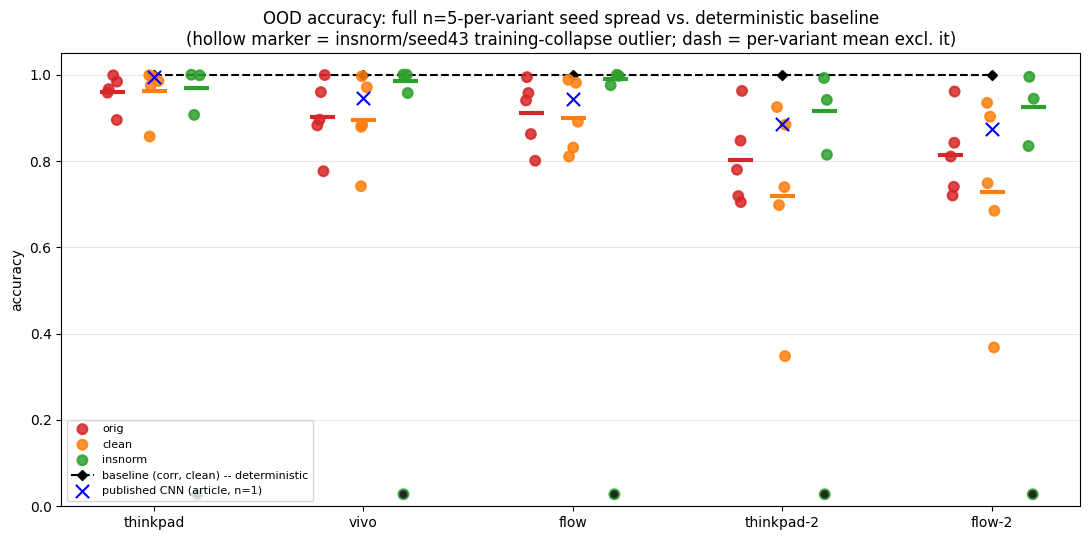

In [14]:
colors = {"orig": "tab:red", "clean": "tab:orange", "insnorm": "tab:green"}
fig, ax = plt.subplots(figsize=(11, 5.5))
x_base = np.arange(len(OOD_DATASETS))
jitter = {"orig": -0.2, "clean": 0.0, "insnorm": 0.2}

for variant in VARIANTS:
    sub = pooled_ood[pooled_ood.variant == variant]
    for i, dataset in enumerate(OOD_DATASETS):
        rows_ = sub[sub.dataset == dataset]
        is_collapse = (variant == "insnorm") & (rows_["seed"] == 43)
        pts = rows_["accuracy"].values
        xs = np.full(len(pts), x_base[i] + jitter[variant]) + np.random.uniform(-0.025, 0.025, len(pts))
        face = ["none" if c else colors[variant] for c in is_collapse.values]
        ax.scatter(xs, pts, edgecolor=colors[variant], facecolor=face, alpha=0.85, s=50, linewidth=1.5,
                   label=variant if i == 0 else None, zorder=3)
    # mean marker (excluding insnorm's collapse seed)
    sub_ex = sub[~((variant == "insnorm") & (sub.seed == 43))]
    means = sub_ex.groupby("dataset")["accuracy"].mean().loc[OOD_DATASETS]
    ax.plot(x_base + jitter[variant], means.values, color=colors[variant], marker="_", markersize=18,
            linewidth=0, markeredgewidth=3, zorder=5)

ax.plot(x_base, [1.0] * len(OOD_DATASETS), color="black", linestyle="--", marker="D", markersize=5,
        label="baseline (corr, clean) -- deterministic", zorder=2)
ax.scatter(x_base, [published_expected[p] for p in OOD_DATASETS], color="blue", marker="x", s=90,
           label="published CNN (article, n=1)", zorder=4)

ax.set_xticks(x_base)
ax.set_xticklabels(OOD_DATASETS)
ax.set_ylabel("accuracy")
ax.set_ylim(0.0, 1.05)
ax.set_title("OOD accuracy: full n=5-per-variant seed spread vs. deterministic baseline\n"
             "(hollow marker = insnorm/seed43 training-collapse outlier; dash = per-variant mean excl. it)")
ax.legend(fontsize=8, loc="lower left")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(OUT_DIR / "plots" / "seed_spread_n5_vs_baseline.png", dpi=130, bbox_inches="tight")
plt.show()

## Phase A2: synthetic overlays across all 15 seeds

Extends the seed-42-only overlay numbers (`orig`/`clean`/`insnorm`) reported for
Table~\ref{tab:aug} in the draft to the full 5-seed protocol, using the same 15 checkpoints
already evaluated on the clean OOD datasets (`weights/` for seed 42, `weights_extra/` for
43--46). 3 variants x 5 seeds x 5 datasets x 3 overlays = 225 forward passes, reusing
`build_model`/`load_weights` from above (cell 5) rather than the broken `load_model()` path.

Question this answers: does `insnorm` (a per-sample operation) close the noise gap the way
per-clip correlation matching closed it for the baseline (Phase A1, `baseline-centroid.ipynb`),
or does noise resist per-sample standardization the way it resists BatchNorm?

In [15]:
import gc, time, psutil

OVERLAY_SUFFIXES = {
    "noise": "noise-interior_domestic",
    "rir": "rir-indoor_no_bathroom",
    "dir": "dir-mic6",
}
OVERLAY_FACTOR = {"noise": "environment", "rir": "environment", "dir": "recording-setting"}
SEEDS = [42, 43, 44, 45, 46]
EXTRA_WEIGHTS_DIR = Path("weights_extra")
CSV_PATH = OUT_DIR / "overlay_pooled_seeds.csv"
LOG_PATH = OUT_DIR / "overlay_progress.log"
MIN_AVAILABLE_GB = 1.5  # abort rather than let the OOM killer pick a victim

def weights_path(variant, seed):
    return WEIGHTS_DIR / f"{variant}-seed{seed}.keras" if seed == 42 else EXTRA_WEIGHTS_DIR / f"{variant}-seed{seed}.keras"

def load_overlay_4d(dataset, overlay):
    dd = np.load(FEATURES_DIR / f"{dataset}-{OVERLAY_SUFFIXES[overlay]}.npz", allow_pickle=True)
    Xo = dd["features"].astype(np.float32)
    if Xo.ndim == 3:
        Xo = Xo[..., None]
    yo = np.array([cidx[v] for v in dd["labels"]])
    return Xo, yo

def log(msg):
    line = f"{time.strftime('%H:%M:%S')} {msg}"
    print(line)
    with open(LOG_PATH, "a") as f:
        f.write(line + "\n")

# Resume support: skip (variant, seed) pairs already checkpointed by a previous attempt.
done_pairs = set()
if CSV_PATH.exists():
    prev = pd.read_csv(CSV_PATH)
    done_pairs = set(map(tuple, prev[["variant", "seed"]].drop_duplicates().values.tolist()))
    log(f"resuming: {len(done_pairs)} (variant,seed) pairs already checkpointed")

open(LOG_PATH, "a").write(f"\n{time.strftime('%H:%M:%S')} === starting overlay eval, {len(VARIANTS)*len(SEEDS)} pairs, {len(done_pairs)} done ===\n")

for variant in VARIANTS:
    for seed in SEEDS:
        if (variant, seed) in done_pairs:
            continue
        avail_gb = psutil.virtual_memory().available / 1e9
        if avail_gb < MIN_AVAILABLE_GB:
            log(f"ABORT: only {avail_gb:.2f} GB available, below {MIN_AVAILABLE_GB} GB floor")
            break
        wp = weights_path(variant, seed)
        if not wp.exists():
            log(f"missing {wp}, skipping")
            continue

        t0 = time.time()
        m = build_model(variant)
        m.load_weights(wp)

        rows = []
        for dataset in OOD_DATASETS:
            for overlay in OVERLAY_SUFFIXES:
                X, y_true = load_overlay_4d(dataset, overlay)
                y_pred = np.argmax(m.predict(X, verbose=0, batch_size=32), axis=1)
                acc = float((y_pred == y_true).mean())
                rows.append({
                    "variant": variant, "seed": seed, "dataset": dataset,
                    "overlay": overlay, "factor": OVERLAY_FACTOR[overlay],
                    "accuracy": acc,
                })
                del X, y_true, y_pred

        del m
        tf.keras.backend.clear_session()
        gc.collect()

        pd.DataFrame(rows).to_csv(CSV_PATH, mode="a", header=not CSV_PATH.exists(), index=False)
        avail_gb = psutil.virtual_memory().available / 1e9
        log(f"{variant} seed{seed} done in {time.time()-t0:.1f}s, {avail_gb:.2f} GB available")

log("=== overlay eval finished ===")
overlay_seed_df = pd.read_csv(CSV_PATH)
overlay_seed_df.shape

01:04:29 orig seed42 done in 27.1s, 8.37 GB available


01:04:55 orig seed43 done in 25.6s, 8.29 GB available


01:05:19 orig seed44 done in 24.5s, 8.35 GB available


01:05:44 orig seed45 done in 24.8s, 8.23 GB available


01:06:09 orig seed46 done in 24.4s, 8.25 GB available


...

01:09:00 insnorm seed43 done in 24.7s, 8.28 GB available


01:09:26 insnorm seed44 done in 25.4s, 8.76 GB available


01:09:50 insnorm seed45 done in 24.6s, 8.83 GB available


01:10:15 insnorm seed46 done in 24.7s, 8.72 GB available
01:10:15 === overlay eval finished ===


(225, 6)

In [2]:
import pandas as pd
from pathlib import Path
OUT_DIR = Path("cross-eval-results")

In [4]:
OUT_DIR = Path("/home/seya/code/chord-detection/training/notebooks/cnn-v2/cross-eval-results")
overlay_seed_df = pd.read_csv(OUT_DIR / "overlay_pooled_seeds.csv")

assert overlay_seed_df.shape[0] == 225
assert set(overlay_seed_df.groupby(["variant", "seed"]).size().values) == {15}
print("gate OK: 225 rows, 15 per (variant, seed)")

overlay_ex = overlay_seed_df[~((overlay_seed_df.variant == "insnorm") & (overlay_seed_df.seed == 43))]
agg = overlay_ex.groupby(["variant", "overlay"])["accuracy"].agg(["mean", "std"]).round(4)
agg

gate OK: 225 rows, 15 per (variant, seed)


mean     std
variant overlay                
clean   dir      0.8239  0.1861
        noise    0.7498  0.1978
        rir      0.7794  0.1646
insnorm dir      0.9655  0.0484
        noise    0.9133  0.0844
        rir      0.9353  0.0690
orig    dir      0.8790  0.1113
        noise    0.7703  0.1493
        rir      0.8166  0.1173

In [5]:
# By factor (environment = noise+rir, recording-setting = dir), and add the
# deterministic baseline (Phase A1) as a reference row.
factor_agg = overlay_ex.groupby(["variant", "factor"])["accuracy"].agg(["mean", "std"]).round(4)
print(factor_agg)

BASELINE_DIR = Path("/home/seya/code/chord-detection/training/notebooks/baseline-centroid/baseline-results")
baseline_overlay = pd.read_csv(BASELINE_DIR / "overlay_summary.csv")
baseline_corr = baseline_overlay[baseline_overlay.metric == "corr"]
print("\nbaseline (corr, clean centroids), by factor:")
print(baseline_corr.groupby("factor")["accuracy"].agg(["mean", "std"]).round(4))

                             mean     std
variant factor                           
clean   environment        0.7646  0.1807
        recording-setting  0.8239  0.1861
insnorm environment        0.9243  0.0769
        recording-setting  0.9655  0.0484
orig    environment        0.7934  0.1349
        recording-setting  0.8790  0.1113

baseline (corr, clean centroids), by factor:
                     mean     std
factor                           
environment        0.9999  0.0004
recording-setting  1.0000  0.0000


## Multi-seed per-class recall

The published error-anatomy narrative (Fig. `perclass`, Table `pairs`: zero recall on
$D$ minor, $E$ diminished, $G\sharp$ diminished) comes from the frozen originally-published
model, not any retrained checkpoint -- confirmed by comparing this session's
`orig`/seed-42 retrain (0.9986/0.9993/0.9944/0.9625/0.9611) against the published numbers
(0.994/0.946/0.944/0.885/0.874): different accuracies despite the same nominal seed and
code, and a different Yamaha failure class (`D_diminished_4` only). This loop evaluates
per-class recall for all 15 retrained checkpoints on all 5 recorded datasets, so the error
anatomy claim can be about the stable part (some class always collapses) rather than a
fixed list from one run.

In [8]:
import gc, time, psutil
from sklearn.metrics import precision_recall_fscore_support

SEEDS = [42, 43, 44, 45, 46]
EXTRA_WEIGHTS_DIR = Path("weights_extra")
PC_CSV = OUT_DIR / "per_class_recall_seeds.csv"
PC_LOG = OUT_DIR / "per_class_recall_progress.log"
MIN_AVAILABLE_GB = 1.5

def weights_path(variant, seed):
    return WEIGHTS_DIR / f"{variant}-seed{seed}.keras" if seed == 42 else EXTRA_WEIGHTS_DIR / f"{variant}-seed{seed}.keras"

def log(msg):
    line = f"{time.strftime('%H:%M:%S')} {msg}"
    print(line)
    with open(PC_LOG, "a") as f:
        f.write(line + "\n")

done_pairs = set()
if PC_CSV.exists():
    prev = pd.read_csv(PC_CSV)
    done_pairs = set(map(tuple, prev[["variant", "seed"]].drop_duplicates().values.tolist()))
    log(f"resuming: {len(done_pairs)} pairs already checkpointed")

for variant in VARIANTS:
    for seed in SEEDS:
        if (variant, seed) in done_pairs:
            continue
        avail_gb = psutil.virtual_memory().available / 1e9
        if avail_gb < MIN_AVAILABLE_GB:
            log(f"ABORT: only {avail_gb:.2f} GB available")
            break
        wp = weights_path(variant, seed)
        if not wp.exists():
            log(f"missing {wp}, skipping")
            continue

        t0 = time.time()
        m = build_model(variant)
        m.load_weights(wp)

        rows = []
        for dataset in OOD_DATASETS:
            X, y_true = ood_data[dataset]
            y_pred = np.argmax(m.predict(X, verbose=0, batch_size=32), axis=1)
            rec_by_class = precision_recall_fscore_support(
                y_true, y_pred, labels=np.arange(36), average=None, zero_division=0
            )[1]
            for ci, cname in enumerate(classes):
                rows.append({
                    "variant": variant, "seed": seed, "dataset": dataset,
                    "class": cname, "recall": float(rec_by_class[ci]),
                })

        del m
        tf.keras.backend.clear_session()
        gc.collect()

        pd.DataFrame(rows).to_csv(PC_CSV, mode="a", header=not PC_CSV.exists(), index=False)
        avail_gb = psutil.virtual_memory().available / 1e9
        log(f"{variant} seed{seed} done in {time.time()-t0:.1f}s, {avail_gb:.2f} GB available")

log("=== per-class recall eval finished ===")
pc_df = pd.read_csv(PC_CSV)
pc_df.shape

02:54:35 orig seed42 done in 7.4s, 6.17 GB available


02:54:40 orig seed43 done in 5.3s, 6.33 GB available


02:54:46 orig seed44 done in 5.3s, 6.38 GB available


02:54:52 orig seed45 done in 5.8s, 6.34 GB available


02:54:57 orig seed46 done in 5.6s, 6.48 GB available


...

02:55:33 insnorm seed43 done in 5.2s, 7.59 GB available


02:55:39 insnorm seed44 done in 5.1s, 7.82 GB available


02:55:44 insnorm seed45 done in 5.0s, 7.85 GB available


02:55:48 insnorm seed46 done in 5.0s, 7.84 GB available
02:55:48 === per-class recall eval finished ===


(2700, 5)

In [9]:
# Fraction of seeds with zero recall, per class, per (variant, dataset) -- the Yamaha datasets
# are where the published narrative's three classes lived.
zero_frac = (
    pc_df.assign(is_zero=(pc_df.recall == 0.0))
    .groupby(["variant", "dataset", "class"])["is_zero"].mean()
)
for variant in VARIANTS:
    for dataset in ["thinkpad-2", "flow-2"]:
        sub = zero_frac.loc[variant, dataset]
        hit = sub[sub > 0].sort_values(ascending=False)
        print(f"{variant} / {dataset}: {len(hit)} classes with >=1 zero-recall seed")
        if len(hit):
            print(hit.round(2).to_string())
        print()

orig / thinkpad-2: 11 classes with >=1 zero-recall seed
class
A_diminished_4     0.6
D_diminished_4     0.6
A#_diminished_4    0.2
A_major_4          0.2
B_major_4          0.2
C#_major_4         0.2
D_major_4          0.2
D_minor_4          0.2
F#_minor_4         0.2
F_diminished_4     0.2
G#_diminished_4    0.2

orig / flow-2: 8 classes with >=1 zero-recall seed
class
A#_minor_4         0.2
A_diminished_4     0.2
B_major_4          0.2
C#_major_4         0.2
D_diminished_4     0.2
D_major_4          0.2
D_minor_4          0.2
G#_diminished_4    0.2

clean / thinkpad-2: 19 classes with >=1 zero-recall seed
class
A_diminished_4     0.8
D_diminished_4     0.4
A#_minor_4         0.4
D_minor_4          0.2
G_major_4          0.2
G#_major_4         0.2
G#_diminished_4    0.2
F_diminished_4     0.2
F#_minor_4         0.2
F#_diminished_4    0.2
A#_diminished_4    0.2
D_major_4          0.2
C#_minor_4         0.2
C#_major_4         0.2
B_minor_4          0.2
B_major_4          0.2
B_diminishe

In [10]:
# Same, insnorm's collapsed seed excluded (seed43 zeroes every class -- not a per-class
# signal, just the whole model being at chance).
pc_ex = pc_df[~((pc_df.variant == "insnorm") & (pc_df.seed == 43))]
zero_frac_ex = (
    pc_ex.assign(is_zero=(pc_ex.recall == 0.0))
    .groupby(["variant", "dataset", "class"])["is_zero"].mean()
)
n_seeds = {"orig": 5, "clean": 5, "insnorm": 4}
for variant in VARIANTS:
    for dataset in ["thinkpad-2", "flow-2"]:
        sub = zero_frac_ex.loc[variant, dataset]
        hit = sub[sub > 0].sort_values(ascending=False)
        print(f"{variant} ({n_seeds[variant]} seeds) / {dataset}: top collapse classes")
        print(hit.head(5).round(2).to_string())
        print()

# Cross-dataset: classes zero-recall on BOTH thinkpad-2 and flow-2 in >=2 seeds, per variant
print("=== zero on both Yamaha datasets in >=2 of their seeds, per variant ===")
for variant in VARIANTS:
    tp2 = zero_frac_ex.loc[variant, "thinkpad-2"]
    fl2 = zero_frac_ex.loc[variant, "flow-2"]
    both = (tp2[tp2 >= 0.4].index).intersection(fl2[fl2 >= 0.4].index)
    print(variant, list(both))

orig (5 seeds) / thinkpad-2: top collapse classes
class
A_diminished_4     0.6
D_diminished_4     0.6
A#_diminished_4    0.2
A_major_4          0.2
B_major_4          0.2

orig (5 seeds) / flow-2: top collapse classes
class
A#_minor_4        0.2
A_diminished_4    0.2
B_major_4         0.2
C#_major_4        0.2
D_diminished_4    0.2

clean (5 seeds) / thinkpad-2: top collapse classes
class
A_diminished_4    0.8
D_diminished_4    0.4
A#_minor_4        0.4
D_minor_4         0.2
G_major_4         0.2

clean (5 seeds) / flow-2: top collapse classes
class
A_diminished_4     0.6
A#_minor_4         0.4
B_major_4          0.4
D_minor_4          0.4
A#_diminished_4    0.2

insnorm (4 seeds) / thinkpad-2: top collapse classes
class
A#_minor_4        0.25
B_diminished_4    0.25
D_diminished_4    0.25
D_minor_4         0.25
F_minor_4         0.25

insnorm (4 seeds) / flow-2: top collapse classes
class
A#_minor_4        0.25
B_diminished_4    0.25
B_major_4         0.25
D_diminished_4    0.25
D_mino

In [11]:
# Save a compact summary for the article figure/table: mean recall + zero-fraction per
# (variant, dataset, class), insnorm's collapsed seed excluded from its own aggregate.
summary_rows = []
for variant in VARIANTS:
    sub = pc_ex[pc_ex.variant == variant]
    agg = sub.groupby(["dataset", "class"])["recall"].agg(["mean", "std", "min", "max"])
    zf = sub.assign(is_zero=(sub.recall == 0.0)).groupby(["dataset", "class"])["is_zero"].mean()
    agg["zero_frac"] = zf
    agg["variant"] = variant
    agg["n_seeds"] = n_seeds[variant]
    summary_rows.append(agg.reset_index())

pc_summary = pd.concat(summary_rows, ignore_index=True)
pc_summary.to_csv(OUT_DIR / "per_class_recall_seed_summary.csv", index=False)

# Sanity check against the old single-seed narrative: the three previously-named classes,
# mean recall (excl. insnorm collapse) across all 5 seeds, on both Yamaha datasets.
FOCUS_CLASSES_OLD = ["D_minor_4", "E_diminished_4", "G#_diminished_4"]
check = pc_summary[(pc_summary["class"].isin(FOCUS_CLASSES_OLD)) & (pc_summary.dataset.isin(["thinkpad-2", "flow-2"]))]
check.pivot_table(index=["dataset", "class"], columns="variant", values=["mean", "zero_frac"]).round(3)

mean                zero_frac             
variant                     clean insnorm   orig     clean insnorm orig
dataset       class                                                       
flow-2     D_minor_4        0.585   0.750  0.660       0.4    0.25  0.2
           E_diminished_4   0.825   1.000  0.995       0.0    0.00  0.0
           G#_diminished_4  0.620   0.831  0.790       0.2    0.00  0.2
thinkpad-2 D_minor_4        0.490   0.712  0.450       0.2    0.25  0.2
           E_diminished_4   0.845   1.000  1.000       0.0    0.00  0.0
           G#_diminished_4  0.640   0.781  0.800       0.2    0.00  0.2